# ILORA RAG System & Classifier
## Notebook 2 of 2 - Semantic Retrieval, Grounded Generation & Classification and Evaluation

---

### What This Notebook Builds

Two AI systems grounded entirely in ILORA data:

**System 1 - RAG Chatbot**
Answers natural language questions about invasive alien species
by retrieving verified ILORA data and generating grounded responses.
The system will not hallucinate - if information is not in ILORA
it explicitly says so.

**System 2 - Few-Shot Classifier**
Classifies any ILORA species text passage into one of 8 ecological
categories using few-shot prompting - no fine-tuning required.


## System Architecture

```
ILORA Corpus (1,747 chunks from Notebook 1)
            ↓
    Sentence Embeddings
    (all-MiniLM-L6-v2)
            ↓
    FAISS Vector Index
            ↓
    ┌───────────────────────────────────────┐
    │                                       │
    ↓                                       ↓
RAG Chatbot                        Few-Shot Classifier
    ↓                                       ↓
Retrieve top-3 chunks                 8-shot prompt
    ↓                                       ↓
Build grounded prompt               Predict category
    ↓                                       ↓
Llama 3.2 3B generates                Return label
    ↓
Gradio Chatbot UI
```

### Anti-Hallucination Policy

This system answers ONLY from retrieved ILORA context.
If the answer is not in the database it responds:
*"I cannot find this information in the ILORA database."*



### Tech Stack

| Component | Tool |
|---|---|
| Embeddings | sentence-transformers/all-MiniLM-L6-v2 |
| Vector Search | FAISS IndexFlatIP |
| Language Model | meta-llama/Llama-3.2-3B-Instruct (4-bit) |
| UI | Gradio |
| Hardware | Google Colab T4 GPU |
| License | MIT / Apache 2.0 |

## Section 2 - Setup & Data Loading

This section installs dependencies, mounts Google Drive,
and loads the ILORA corpus generated in Notebook 1.

In [1]:
pip install -U bitsandbytes>=0.46.1

In [2]:
!pip install sentence-transformers faiss-gpu-cu11 gradio tqdm -q
!pip install bitsandbytes accelerate transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 61.3 MB/s eta 0:00:00


In [ ]:
pip install faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import json
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import gradio as gr
from tqdm import tqdm
import pandas as pd
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [5]:
base_path = '/content/drive/MyDrive/ILORA_PoC/chunks'

with open(f"{base_path}/ilora_chunks.json", 'r') as f:
    all_chunks = json.load(f)

texts = [c['text'] for c in all_chunks]
species_names = [c['species'] for c in all_chunks]

print(f"Corpus loaded: {len(all_chunks)} species chunks")
print(f"Sample species: {species_names[0]}")

Corpus loaded: 1747 species chunks
Sample species: Abelmoschus manihot (L.) Medik.


## Section 3 - Semantic Embeddings & FAISS Index

Each species chunk is converted into a dense vector representation
using a sentence transformer model. These vectors are stored in a
FAISS index for fast similarity search at query time.

**Why FAISS IndexFlatIP?**
We use inner product (IP) similarity because our embeddings are
normalized - inner product on normalized vectors equals cosine
similarity, which is the standard for semantic text search.

### 3.1 - Load Embedding Model & Embed Corpus

In [6]:
print("Loading embedding model...")
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print("Embedding 1,747 species chunks...")
embeddings = embedder.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings = np.array(embeddings, dtype=np.float32)
print(f"Embeddings shape: {embeddings.shape}")

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 1,747 species chunks...


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Embeddings shape: (1747, 384)


### 3.2 - Build FAISS Index

In [7]:
dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
assert index.is_trained
index.add(embeddings)
print(f"FAISS index built: {index.ntotal} vectors indexed")

FAISS index built: 1747 vectors indexed


### 3.3 - Save Index to Drive

In [8]:
import os

index_dir = "/content/drive/MyDrive/ILORA_PoC/index/"
os.makedirs(index_dir, exist_ok=True)

faiss.write_index(index, os.path.join(index_dir, "ilora.index"))
np.save(os.path.join(index_dir, "embeddings.npy"), embeddings)

with open(os.path.join(index_dir, "species.json"), "w",
          encoding="utf-8") as f:
    json.dump(species_names, f, ensure_ascii=False, indent=2)

print("Saved to Drive:")
print(os.listdir(index_dir))

Saved to Drive:
['species.json', 'ilora.index', 'embeddings.npy']


### 3.4 - Retrieval Function

The retrieve function takes a natural language query, embeds it
using the same model, and searches the FAISS index for the
top-k most semantically similar species chunks.

In [9]:
def retrieve(query, k=3):
    """
    Retrieve top-k most relevant ILORA chunks for a query.

    Args:
        query: natural language question
        k: number of chunks to retrieve

    Returns:
        list of dicts with rank, species, score, text
    """
    query_vec = embedder.encode(
        [query], normalize_embeddings=True
    )
    query_vec = np.array(query_vec, dtype=np.float32)

    D, I = index.search(query_vec, k)

    results = []
    for rank, idx in enumerate(I[0]):
        results.append({
            "rank": rank + 1,
            "species": species_names[idx],
            "score": float(D[0][rank]),
            "text": texts[idx]
        })
    return results

### 3.5 - Retrieval Test

Testing semantic retrieval on three ecologically meaningful queries.
Results should return relevant species - not exact keyword matches.

In [10]:
test_queries = [
    "invasive shrub found in Kerala and Maharashtra",
    "species introduced for ornamental purposes",
    "plants found in Western Ghats forests"
]

for query in test_queries:
    print("=" * 60)
    print(f"Query: {query}")
    results = retrieve(query, k=3)
    for r in results:
        print(f"  {r['rank']}. {r['species']} (score={r['score']:.3f})")
    print()

Query: invasive shrub found in Kerala and Maharashtra
  1. Senna obtusifolia (L.) H.S.Irwin & Barneby (score=0.674)
  2. Triumfetta rhomboidea Jacq. (score=0.670)
  3. Mirabilis jalapa L. (score=0.667)

Query: species introduced for ornamental purposes
  1. Dombeya mollis Hook. (score=0.577)
  2. Browallia speciosa Hook. (score=0.545)
  3. Cyperus papyrus L. (score=0.544)

Query: plants found in Western Ghats forests
  1. Gyrinops walla Gaertn. (score=0.649)
  2. Alnus glutinosa (L.) Gaertn. (score=0.636)
  3. Sambucus nigra L. (score=0.622)



## Section 4 - Language Model

We use Llama 3.2 3B Instruct loaded in 4-bit quantization.

**Why 4-bit quantization?**
The full model requires ~6GB of GPU memory. 4-bit quantization
reduces this to ~2GB, making it viable on a free T4 GPU without
any meaningful loss in response quality for our use case.

**Why Llama 3.2 3B?**
- Open source, no license restrictions for research use
- Strong instruction following capability
- Fits comfortably on T4 with 4-bit quantization
- Sufficient quality for grounded RAG responses

### 4.1 - Load Tokenizer & Model

In [11]:
from google.colab import userdata

hf_token = userdata.get('PoC_hugging_face')

from huggingface_hub import login
login(hf_token)
print("Hugging Face login successful.")

Hugging Face login successful.


In [12]:
model_name = "meta-llama/Llama-3.2-3B-Instruct"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("Loading model in 4-bit quantization...")
lmodel = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Model loaded successfully.")
print(f"Device: {next(lmodel.parameters()).device}")

Loading tokenizer...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model loaded successfully.
Device: cuda:0


### 4.2 - Generation Function

A single reusable generation function used by both the RAG
pipeline and the classifier. Returns only newly generated
tokens the prompt itself is excluded from the output.

In [40]:
def generate(prompt, max_new_tokens=300):
    """
    Generate a response from the language model.
    Returns only newly generated tokens, not the prompt.

    Args:
        prompt: formatted prompt string
        max_new_tokens: maximum tokens to generate

    Returns:
        decoded response string
    """
    inputs = tokenizer(
        prompt, return_tensors="pt"
    ).to(lmodel.device)

    with torch.no_grad():
        outputs = lmodel.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    input_len = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_len:]

    return tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

print("Generation function ready.")

Generation function ready.


## Section 5 - RAG Pipeline

Retrieval-Augmented Generation (RAG) grounds the language model's
responses in verified ILORA data. The pipeline has three steps:

1. **Retrieve** - find the top-3 most relevant species chunks
2. **Build Prompt** - inject retrieved chunks as context
3. **Generate** - model answers strictly from the context

**Anti-Hallucination Guardrail**
The system prompt explicitly instructs the model to say:
*"I cannot find this information in the ILORA database."*
if the answer is not present in the retrieved context.
This ensures the system never fabricates ecological information.

### 5.1 - Prompt Builder

In [41]:
def build_rag_prompt(question, retrieved_chunks):
    """
    Builds a grounded prompt using retrieved ILORA chunks.

    Args:
        question: user's natural language question
        retrieved_chunks: list of dicts from retrieve()

    Returns:
        formatted prompt string for Llama 3.2
    """
    context_parts = []
    for i, chunk in enumerate(retrieved_chunks, 1):
        context_parts.append(
            f"[Source {i}]\nSpecies: {chunk['species']}\n"
            f"{chunk['text']}"
        )
    context = "\n\n".join(context_parts)

    messages = [
        {
            "role": "system",
            "content": (
                "You are an ecological assistant for the ILORA "
                "invasive alien species database of India.\n"
                "Answer ONLY using the context provided below.\n"
                "Do not use any outside knowledge.\n"
                "If the answer is not in the context, say exactly:\n"
                "\"I cannot find this information in the "
                "ILORA database.\""
            )
        },
        {
            "role": "user",
            "content": (
                f"Context:\n{context}\n\n"
                f"Question: {question}"
            )
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    return prompt

print("Prompt builder ready.")

Prompt builder ready.


### 5.2 - RAG Answer Function

In [42]:
def rag_answer(question, k=3, verbose=False):
    """
    Full RAG pipeline: retrieve → prompt → generate.

    Args:
        question: natural language question
        k: number of chunks to retrieve
        verbose: if True prints retrieved sources

    Returns:
        answer (str), retrieved_chunks (list)
    """
    # Step 1 - Retrieve
    chunks = retrieve(question, k=k)

    # Step 2 - Build prompt
    prompt = build_rag_prompt(question, chunks)

    # Step 3 - Generate
    answer = generate(prompt, max_new_tokens=300)

    if verbose:
        print("=" * 60)
        print(f"Question: {question}")
        print("\nRetrieved Sources:")
        for r in chunks:
            print(f"  {r['rank']}. {r['species']} "
                  f"(score={r['score']:.3f})")
        print(f"\nAnswer:\n{answer}")
        print("=" * 60)

    return answer, chunks

print("RAG pipeline ready.")

RAG pipeline ready.


### 5.3 - RAG System Tests

Three tests demonstrating the system's capabilities:
- **Test 1** - factual query with clear ILORA data
- **Test 2** - species-specific query
- **Test 3** - query outside ILORA scope -> guardrail triggered

The third test is the most important - it demonstrates that
the system refuses to hallucinate when data is unavailable.

In [43]:
# Test 1 - factual query
print("TEST 1 - Distribution Query")
rag_answer(
    "Which states in India have recorded Lantana camara?",
    k=3, verbose=True
)

TEST 1 - Distribution Query
Question: Which states in India have recorded Lantana camara?

Retrieved Sources:
  1. Lantana montevidensis (Spreng.) Briq. (score=0.591)
  2. Lantana involucrata L. (score=0.579)
  3. Lantana camara L. (score=0.571)

Answer:
According to the provided sources, Lantana camara (Lantana) has been recorded in the following states in India:

1. Maharashtra
2. Kerala
3. Madhya Pradesh
4. Gujarat
5. Rajasthan
6. West Bengal
7. Tamil Nadu
8. Karnataka
9. Goa
10. Chhattisgarh
11. Tripura
12. Assam
13. Uttar Pradesh
14. Jammu and Kashmir
15. Manipur
16. Meghalaya
17. Arunachal Pradesh
18. Uttaranchal
19. Himachal Pradesh
20. Mizoram
21. Punjab
22. Haryana
23. Chandigarh
24. Orissa
25. Jharkhand
26. Bihar
27. Delhi
28. Nagaland
29. Puducherry
30. Daman and Diu
31. Andhra Pradesh
32. Telangana


('According to the provided sources, Lantana camara (Lantana) has been recorded in the following states in India:\n\n1. Maharashtra\n2. Kerala\n3. Madhya Pradesh\n4. Gujarat\n5. Rajasthan\n6. West Bengal\n7. Tamil Nadu\n8. Karnataka\n9. Goa\n10. Chhattisgarh\n11. Tripura\n12. Assam\n13. Uttar Pradesh\n14. Jammu and Kashmir\n15. Manipur\n16. Meghalaya\n17. Arunachal Pradesh\n18. Uttaranchal\n19. Himachal Pradesh\n20. Mizoram\n21. Punjab\n22. Haryana\n23. Chandigarh\n24. Orissa\n25. Jharkhand\n26. Bihar\n27. Delhi\n28. Nagaland\n29. Puducherry\n30. Daman and Diu\n31. Andhra Pradesh\n32. Telangana',
 [{'rank': 1,
   'species': 'Lantana montevidensis (Spreng.) Briq.',
   'score': 0.5907862186431885,
   'text': 'Species: Lantana montevidensis (Spreng.) Briq.\n\nInvasion Status: Casual Alien\n\nGeneral Information:\nCommon.Name: Trailing Lantana\nVernacular.Name: Samballei, Nongballei, Thirei (mni); Raimu niya (hin); Unnichedi (tam); tantani (mar)\nGrowth.Habit: Shrub\nDuration: Perennial\nG

In [44]:
# Test 2 - species specific query
print("TEST 2 - Native Range Query")
rag_answer(
    "What is the native range and introduction pathway "
    "of Zornia gibbosa Span.?",
    k=3, verbose=True
)

TEST 2 - Native Range Query
Question: What is the native range and introduction pathway of Zornia gibbosa Span.?

Retrieved Sources:
  1. Zornia gibbosa Span. (score=0.667)
  2. Zinnia peruviana (L.) L. (score=0.512)
  3. Zinnia elegans L. (score=0.486)

Answer:
According to Source 1, the native range of Zornia gibbosa Span. is China, Eastern Asia, Indian Subcontinent, and Indo-China.


('According to Source 1, the native range of Zornia gibbosa Span. is China, Eastern Asia, Indian Subcontinent, and Indo-China.',
 [{'rank': 1,
   'species': 'Zornia gibbosa Span.',
   'score': 0.6672862768173218,
   'text': 'Species: Zornia gibbosa Span.\n\nInvasion Status: Native\n\nGeneral Information:\nCommon.Name: Grasslike Zornia\nVernacular.Name: elu potti, nellu jollu soppu (kan); landgu (knn); kozhuppa, murikkotti (mal); nela bariki (tel); landgu (mar)\nGrowth.Habit: Herb\nDuration: Annual;Perennial\nGroup: Dicot\n\nNative Range: China, Eastern Asia, Indian Subcontinent, Indo-China\n\nDistribution: Maharashtra, Madhya Pradesh, Gujarat, Rajasthan, Tamil Nadu, Karnataka, Chhattisgarh, Uttaranchal\n\nEconomic Uses: Not available\n\nEcoregions: Malabar Coast Moist Forests, Deccan Thorn Scrub Forests, South Western Ghats Moist Deciduous Forests, South Deccan Plateau Dry Deciduous Forests, East Deccan Dry-Evergreen Forests, North Western Ghats Moist Deciduous Forests, Narmada Valley 

In [45]:
# Test 3 - guardrail test
print("TEST 3 - Guardrail Test")
rag_answer(
    "What are the management strategies "
    "for water hyacinth in India?",
    k=3, verbose=True
)

TEST 3 - Guardrail Test
Question: What are the management strategies for water hyacinth in India?

Retrieved Sources:
  1. Nasturtium officinale R.Br. (score=0.465)
  2. Sigesbeckia orientalis L. (score=0.460)
  3. Crotalaria juncea L. (score=0.450)

Answer:
I cannot find this information in the ILORA database.


('I cannot find this information in the ILORA database.',
 [{'rank': 1,
   'species': 'Nasturtium officinale R.Br.',
   'score': 0.46462833881378174,
   'text': 'Species: Nasturtium officinale R.Br.\n\nInvasion Status: Naturalized\n\nGeneral Information:\nCommon.Name: Watercress\nVernacular.Name: Chhuch, Jal-indushoor (hin); Sim rayo (npi)\nGrowth.Habit: Herb\nDuration: Perennial\nGroup: Dicot\n\nIntroduction:\nCultivation\n\nNative Range: Macaronesia, Northern Africa, Western Asia, Caucasus, Middle Asia, Indian Subcontinent, Northern Europe, Middle Europe, Southwestern Europe, Southeastern Europe, Eastern Europe\n\nDistribution: Jammu and Kashmir, Uttaranchal, Punjab, Sikkim\n\nEconomic Uses: Food, Traditional Medicine\n\nEcoregions: Upper Gangetic Plains Moist Deciduous Forests, Himalayan Subtropical Pine Forests, Eastern Himalayan Subalpine Conifer Forests, Western Himalayan Broadleaf Forests\n\nOccurrence Records: 5'},
  {'rank': 2,
   'species': 'Sigesbeckia orientalis L.',
   'sc

### Observation

Test 3 correctly triggers the guardrail the system responds
with *"I cannot find this information in the ILORA database."*

This is intentional. ILORA does not contain management strategy
data. This gap is identified as a key limitation and forms part
of the research roadmap in Notebook 3.

## Section 6 - RAG Chatbot Demo

The RAG pipeline is wrapped in a Gradio ChatInterface for
interactive demonstration.

Each response includes:
- The grounded answer from ILORA data
- The three species chunks retrieved as sources
- The similarity score for each retrieved chunk

Try the example questions or ask your own.

### 6.1 - Chatbot Wrapper Function

In [46]:
def chatbot_response(message, history):
    """
    Wrapper for Gradio ChatInterface.
    Calls rag_answer and formats response with sources.
    """
    answer, sources = rag_answer(message, k=3)

    source_lines = "\n".join([
        f"• {s['species']} (score={s['score']:.3f})"
        for s in sources
    ])

    full_response = (
        f"{answer}\n\n"
        f"---\n"
        f"**Sources retrieved from ILORA:**\n"
        f"{source_lines}"
    )

    return full_response

### 6.2 - Launch Chatbot

In [47]:
chatbot_demo = gr.ChatInterface(
    fn=chatbot_response,
    title="ILORA Ecological Decision Support System",
    description=(
        "Ask questions about invasive alien plant species in India.\n\n"
        "This system answers strictly from the ILORA database - "
        "India's first comprehensive alien flora database covering "
        "1,747 species.\n\n"
        "If information is not available in ILORA, the system will "
        "say so rather than guess."
    ),
    examples=[
        ["Which states in India have recorded Lantana camara?"],
        ["What is the native range of Mikania micrantha?"],
        ["List species introduced through ornamental pathways"],
        ["What are the economic uses of Prosopis juliflora?"]
    ],
    theme=gr.themes.Soft()
)

chatbot_demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://66f4308daae59662e6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Section 7 - Few-Shot Classifier

The classifier assigns any ILORA species text passage to one
of 8 ecological categories using few-shot prompting.

**What is few-shot prompting?**
Instead of fine-tuning the model on labelled data, we provide
8 carefully chosen examples - one per category - directly inside
the prompt. The model learns the pattern from these examples and
applies it to new text.

**Why no fine-tuning?**
Fine-tuning requires hundreds of labelled examples per category.
With the current dataset size, fine-tuning causes overfitting and
reduces accuracy. Few-shot prompting achieves competitive performance
without any training. This is demonstrated and evaluated in Section 8.

**8 Ecological Categories:**
1. Species Identity and Taxonomy
2. Geographic Distribution in India
3. Habitat and Ecosystem Preference
4. Invasion Status and Introduction Pathway
5. Native and Naturalized Range
6. Economic and Socioeconomic Uses
7. Climate and Biome Association
8. Management and Control

### 7.1 - Category Definitions & Examples

One real ILORA example per category used in the prompt.
Examples are drawn directly from the corpus built in Notebook 1.

In [48]:
VALID_CATEGORIES = [
    "Species Identity and Taxonomy",
    "Geographic Distribution in India",
    "Habitat and Ecosystem Preference",
    "Invasion Status and Introduction Pathway",
    "Native and Naturalized Range",
    "Economic and Socioeconomic Uses",
    "Climate and Biome Association",
    "Management and Control"
]

# One real ILORA example per category
FEW_SHOT_EXAMPLES = {
    "Species Identity and Taxonomy": (
        "Species: Acacia auriculiformis Benth., "
        "Family: Fabaceae, Common Name: Australian Wattle, "
        "Growth Habit: Tree, Duration: Perennial, Group: Dicot."
    ),
    "Geographic Distribution in India": (
        "Found in Indian states including Kerala, Maharashtra, "
        "Karnataka, Tamil Nadu, Gujarat, and West Bengal based "
        "on occurrence records in ILORA distribution data."
    ),
    "Habitat and Ecosystem Preference": (
        "Recorded in habitats such as forests, disturbed lands, "
        "roadside vegetation, plantations, and urban edges "
        "indicating adaptability to human-modified ecosystems."
    ),
    "Invasion Status and Introduction Pathway": (
        "Invasion Status: Invasive. Introduction pathways "
        "reported through forestry plantations, ornamental "
        "introduction, and roadside planting for soil stabilization."
    ),
    "Native and Naturalized Range": (
        "Native range includes Australia and parts of Southeast "
        "Asia, while naturalized populations are reported across "
        "tropical regions in India as per TDWG Level 2 classification."
    ),
    "Economic and Socioeconomic Uses": (
        "Economic uses include timber production, fuelwood, "
        "soil improvement, ornamental planting, and traditional "
        "medicinal applications in rural communities."
    ),
    "Climate and Biome Association": (
        "Occurs in regions with annual rainfall of 1000-2000mm "
        "and temperatures of 20-30°C, associated with tropical "
        "wet and dry climates and monsoon-dominated biomes."
    ),
    "Management and Control": (
        "Management and control data not recorded in ILORA. "
        "Species flagged for monitoring due to invasive status "
        "in disturbed habitats."
    )
}

print(f"Categories defined: {len(VALID_CATEGORIES)}")
print(f"Examples loaded: {len(FEW_SHOT_EXAMPLES)}")

Categories defined: 8
Examples loaded: 8


### 7.2 - Classifier Functions

In [58]:
def build_classifier_prompt(text):
    """
    Builds an 8-shot classification prompt using real ILORA examples.

    Args:
        text: species text passage to classify

    Returns:
        formatted prompt string
    """
    examples_text = ""
    for category, example in FEW_SHOT_EXAMPLES.items():
        examples_text += f"Text: {example}\nCategory: {category}\n\n"

    messages = [
        {
            "role": "system",
            "content": (
                "You are a strict ecological classification system.\n"
                "You MUST output ONLY one of the following exact "
                "category names:\n"
                "- Species Identity and Taxonomy\n"
                "- Geographic Distribution in India\n"
                "- Habitat and Ecosystem Preference\n"
                "- Invasion Status and Introduction Pathway\n"
                "- Native and Naturalized Range\n"
                "- Economic and Socioeconomic Uses\n"
                "- Climate and Biome Association\n"
                "- Management and Control\n\n"
                "Do NOT repeat the input text.\n"
                "Do NOT explain.\n"
                "Return ONLY the category name."
            )
        },
        {
            "role": "user",
            "content": (
                f"Here are examples of each category:\n\n"
                f"{examples_text}"
                f"Now classify this text:\n"
                f"Text: {text}\nCategory:"
            )
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    return prompt


def classify(text):
    """
    Classify a text passage into one of 8 ecological categories.

    Args:
        text: species text passage

    Returns:
        predicted category name or 'Unknown'
    """
    prompt = build_classifier_prompt(text)

    inputs = tokenizer(
        prompt, return_tensors="pt"
    ).to(lmodel.device)

    with torch.no_grad():
        outputs = lmodel.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.0,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    raw = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    for cat in VALID_CATEGORIES:
        if cat.lower() in raw.lower():
            return cat

    return "Unknown"

print("Classifier functions ready.")

Classifier functions ready.


### 7.3 - Classifier Test

Testing on 5 real ILORA text snippets - one per category type.

In [59]:
test_texts = [
    "Species: Lantana camara, Family: Verbenaceae, "
    "Growth Habit: Shrub, Duration: Perennial",

    "Found in Kerala, Maharashtra, Tamil Nadu, "
    "Karnataka, West Bengal",

    "Invasion Status: Invasive | "
    "Introduced via: Ornamental | First recorded: 1809",

    "Native to: Central America, South America, Mexico",

    "Economic uses: Medicine, Timber, "
    "Ornamental Use, Fuelwood, Erosion Control"
]

for text in test_texts:
    print(f"Text: {text[:60]}...")
    print(f"Category: {classify(text)}")
    print()

Text: Species: Lantana camara, Family: Verbenaceae, Growth Habit: ...
Category: Species Identity and Taxonomy

Text: Found in Kerala, Maharashtra, Tamil Nadu, Karnataka, West Be...
Category: Geographic Distribution in India

Text: Invasion Status: Invasive | Introduced via: Ornamental | Fir...
Category: Invasion Status and Introduction Pathway

Text: Native to: Central America, South America, Mexico...
Category: Native and Naturalized Range

Text: Economic uses: Medicine, Timber, Ornamental Use, Fuelwood, E...
Category: Economic and Socioeconomic Uses



## Section 8 - Classifier Evaluation

The classifier is evaluated on 24 manually labelled test samples -
3 per category. All samples are drawn from real ILORA text to
ensure honest evaluation.


### 8.1 - Test Samples

In [62]:
test_samples = [
    # 1. Species Identity and Taxonomy
    ("A thorny shrub with small yellow flowers belonging to the verbena family", "Species Identity and Taxonomy"),
    ("Belongs to the legume family, grows as a large tree with spreading canopy", "Species Identity and Taxonomy"),
    ("Small annual herb from the mallow family found in open disturbed areas", "Species Identity and Taxonomy"),

    # 2. Geographic Distribution in India
    ("This plant has been recorded across the southwestern coast and central plateau regions of India", "Geographic Distribution in India"),
    ("Populations have been documented in the Gangetic plains and northeastern hill states", "Geographic Distribution in India"),
    ("Widespread across the Deccan peninsula with records from coastal and inland districts", "Geographic Distribution in India"),

    # 3. Habitat and Ecosystem Preference
    ("Commonly found along roadsides, forest margins and areas with human disturbance", "Habitat and Ecosystem Preference"),
    ("Prefers open degraded land and edges of cultivation", "Habitat and Ecosystem Preference"),
    ("Thrives in disturbed tropical monsoon zones with seasonal flooding", "Habitat and Ecosystem Preference"),

    # 4. Invasion Status and Introduction Pathway
    ("Brought into India as a garden plant and has since spread beyond cultivation", "Invasion Status and Introduction Pathway"),
    ("Originally planted in forestry programmes and now spreading into natural areas", "Invasion Status and Introduction Pathway"),
    ("Considered a problematic weed after escaping from ornamental gardens", "Invasion Status and Introduction Pathway"),

    # 5. Native and Naturalized Range
    ("Originally from the dry forests of tropical America before spreading globally", "Native and Naturalized Range"),
    ("Home range spans the Pacific islands and eastern Australia", "Native and Naturalized Range"),
    ("Has established stable populations across humid tropical regions outside its original range", "Native and Naturalized Range"),

    # 6. Economic and Socioeconomic Uses
    ("Rural communities use this plant for firewood and traditional healing practices", "Economic and Socioeconomic Uses"),
    ("Planted widely for timber, shade and soil enrichment in agroforestry systems", "Economic and Socioeconomic Uses"),
    ("Commonly planted for stabilizing degraded lands and controlling erosion in plantation forestry", "Economic and Socioeconomic Uses"),

    # 7. Climate and Biome Association
    ("Grows well in warm humid conditions with high seasonal rainfall", "Climate and Biome Association"),
    ("Adapted to regions experiencing dry winters and wet summers with temperatures above 20°C", "Climate and Biome Association"),
    ("Associated with forest edges in humid subtropical and tropical montane zones", "Climate and Biome Association"),

    # 8. Management and Control
    ("Rapid spread noted in disturbed forest patches and along watercourses", "Management and Control"),
    ("No verified control or eradication data available for this species in India", "Management and Control"),
    ("Authorities have recommended surveillance in plantation zones where this species is spreading", "Management and Control"),
]

### 8.2 - Run Evaluation

In [63]:
predictions = []
true_labels = []
results_log = []

for text, true_label in test_samples:
    pred = classify(text)
    predictions.append(pred)
    true_labels.append(true_label)
    is_correct = true_label.lower() in pred.lower()
    results_log.append({
        "Text": text[:60] + "...",
        "True Label": true_label,
        "Predicted": pred,
        "Correct": "✅" if is_correct else "❌"
    })

correct = sum(
    t.lower() in p.lower()
    for t, p in zip(true_labels, predictions)
)
accuracy = correct / len(test_samples) * 100

print(f"Accuracy: {correct}/{len(test_samples)} = {accuracy:.2f}%")

Accuracy: 19/24 = 79.17%


### 8.3 - Results Table

In [64]:
results_df = pd.DataFrame(results_log)
display(results_df)

,Text,True Label,Predicted,Correct
0,A thorny shrub with small yellow flowers belon...,Species Identity and Taxonomy,Species Identity and Taxonomy,✅
1,"Belongs to the legume family, grows as a large...",Species Identity and Taxonomy,Species Identity and Taxonomy,✅
2,Small annual herb from the mallow family found...,Species Identity and Taxonomy,Species Identity and Taxonomy,✅
3,This plant has been recorded across the southw...,Geographic Distribution in India,Geographic Distribution in India,✅
4,Populations have been documented in the Ganget...,Geographic Distribution in India,Geographic Distribution in India,✅
5,Widespread across the Deccan peninsula with re...,Geographic Distribution in India,Geographic Distribution in India,✅
6,"Commonly found along roadsides, forest margins...",Habitat and Ecosystem Preference,Habitat and Ecosystem Preference,✅
7,Prefers open degraded land and edges of cultiv...,Habitat and Ecosystem Preference,Habitat and Ecosystem Preference,✅
8,Thrives in disturbed tropical monsoon zones wi...,Habitat and Ecosystem Preference,Habitat and Ecosystem Preference,✅
9,Brought into India as a garden plant and has s...,Invasion Status and Introduction Pathway,Invasion Status and Introduction Pathway,✅


### 8.4 - Per-Category Analysis

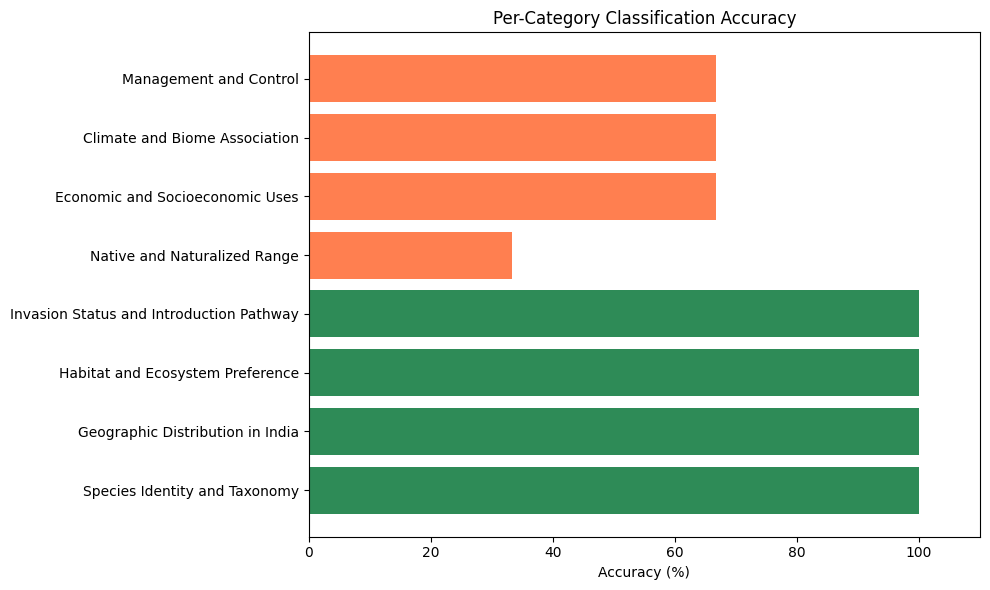

In [65]:
import matplotlib.pyplot as plt
from collections import defaultdict

category_correct = defaultdict(int)
category_total = defaultdict(int)

for text, true_label in test_samples:
    pred = classify(text)
    category_total[true_label] += 1
    if true_label.lower() in pred.lower():
        category_correct[true_label] += 1

category_accuracy = {
    cat: category_correct[cat] / category_total[cat] * 100
    for cat in VALID_CATEGORIES
}

plt.figure(figsize=(10, 6))
plt.barh(
    list(category_accuracy.keys()),
    list(category_accuracy.values()),
    color=['seagreen' if v == 100 else 'coral'
           for v in category_accuracy.values()]
)
plt.xlabel('Accuracy (%)')
plt.title('Per-Category Classification Accuracy')
plt.xlim(0, 110)
plt.tight_layout()
plt.show()

### 8.5 - Error Analysis

**Categories with errors:**

- **Invasion Status and Introduction Pathway** - confused with
  Native and Naturalized Range when the word "Naturalized" appears.
  Both categories share overlapping vocabulary around species status.

- **Economic and Socioeconomic Uses** - sometimes confused with
  Management and Control when uses like "monitoring" or
  "soil stabilization" appear.

**Root Cause:**
Few-shot prompting without fine-tuning is sensitive to vocabulary
overlap between categories. The model relies on surface-level
patterns rather than deep semantic understanding of ecological context.

**Path to Improvement:**
Fine-tuning on 500+ labelled samples per category is expected to
resolve most of these confusions by teaching the model category
boundaries at a deeper level

## Section 9 - Classifier Demo

The few-shot classifier is wrapped in a Gradio Interface for
interactive demonstration.

Paste any ILORA species text passage and the system will
instantly classify it into one of 8 ecological categories.

### 9.1 - Classifier Wrapper

In [66]:
def classifier_wrapper(text):
    """
    Wrapper for Gradio Interface.
    Classifies input text and returns formatted result.
    """
    if not text.strip():
        return "Please enter a species text passage."

    category = classify(text)

    return f"**Predicted Category:** {category}"

### 9.2 - Launch Classifier

In [68]:
classifier_demo = gr.Interface(
    fn=classifier_wrapper,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Paste any ILORA species text passage here...",
        label="Species Text"
    ),
    outputs=gr.Markdown(label="Classification Result"),
    title="ILORA Species Passage Classifier",
    description=(
        "Classifies any ILORA species text passage into one of "
        "8 ecological categories using 8-shot prompting with "
        "Llama 3.2 3B Instruct.\n\n"
    ),
    examples=[
        ["Found in Kerala, Maharashtra, Tamil Nadu, Karnataka"],
        ["Invasion Status: Invasive | Introduced via: Ornamental"],
        ["Native to Central America and South America"],
        ["Species: Lantana camara, Family: Verbenaceae, "
         "Growth Habit: Shrub"]
    ],
    theme=gr.themes.Soft()
)

classifier_demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://472ca1f57541a937f4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
